# Resolução: Looqbox Data Challenge

**Candidato:** Gabriel Sales Ribeiro

**Data:** 27/05/2026

### Declaração de Transparência sobre o Uso de IA
Conforme orientado nas orientações do teste, declaro que utilizei Inteligência Artificial (Gemini) de forma pontual como ferramenta de apoio para algumas estruturações no ambiente e apoio em Debugging. Ressalto que toda a lógica de negócio, decisões arquiteturais do código, além da validação final de todos os resultados, foram feitas integralmente por mim, garantindo total domínio sobre cada linha executada neste Notebook.


---

## Preparação do Ambiente
Vamos primeiro realizar a instalação das bibliotecas necessárias e definir uma função de conexão com o banco MySQL (`get_connection`).

---

In [3]:
!pip install pymysql pandas matplotlib seaborn

import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [4]:
def get_connection():
    return pymysql.connect(
        host='35.199.115.174',
        user='looqbox-challenge',
        password='looq-challenge',
        database='looqbox-challenge'
    )

---

## 1. Teste SQL

As queries solicitadas foram construídas e executadas diretamente no banco de dados da Looqbox. Decidi colocar as queries na biblioteca Pandas para exibir os outputs em formato de tabela interativa e formatada, para facilitar a leitura neste documento.

### Questão 1: Quais são os 10 produtos mais caros da empresa?

---

In [5]:
query_sql_1 = """
SELECT
    PRODUCT_COD,
    PRODUCT_NAME,
    PRODUCT_VAL
FROM data_product
ORDER BY PRODUCT_VAL DESC
LIMIT 10;
"""
with get_connection() as conn:
    df_sql_1 = pd.read_sql(query_sql_1, con=conn)

display(df_sql_1)

,PRODUCT_COD,PRODUCT_NAME,PRODUCT_VAL
0,301409,Whisky Escoces THE MACALLAN Ruby Garrafa 700ml...,741.99
1,176185,Whisky Escoces JOHNNIE WALKER Blue Label Garra...,735.90
2,315481,Cafeteira Expresso 3 CORACOES Tres Modo Vermelho,499.00
3,100280,Vinho Portugues Tinto Vintage QUINTA DO CRASTO...,445.90
4,320046,Escova Dental Eletrica ORAL B D34 Professional...,399.90
5,190817,Champagne Rose VEUVE CLICQUOT PONSARDIM Garraf...,366.90
6,153795,Champagne Frances Brut Imperial MOET Rose Garr...,359.90
7,311397,Conjunto de Panelas Allegra em Inox TRAMONTINA...,359.00
8,147706,Whisky Escoces CHIVAS REGAL 18 Anos Garrafa 750ml,329.90
9,154431,Champagne Frances Brut Imperial MOET & CHANDON...,315.90


---

### Questão 2: Quais são as secções dos departamentos 'BEBIDAS' e 'PADARIA'?

---

In [6]:
query_sql_2 = """
SELECT DISTINCT
    DEP_NAME,
    SECTION_NAME
FROM data_product
WHERE DEP_NAME IN ('BEBIDAS', 'PADARIA')
ORDER BY DEP_NAME, SECTION_NAME;
"""
with get_connection() as conn:
    df_sql_2 = pd.read_sql(query_sql_2, con=conn)

display(df_sql_2)

,DEP_NAME,SECTION_NAME
0,BEBIDAS,BEBIDAS
1,BEBIDAS,CERVEJAS
2,BEBIDAS,REFRESCOS
3,BEBIDAS,VINHOS
4,PADARIA,DOCES-E-SOBREMESAS
5,PADARIA,GESTANTE
6,PADARIA,PADARIA
7,PADARIA,QUEIJOS-E-FRIOS


---

### Questão 3: Qual foi a venda total de produtos (em $) de cada Área de Negócio no primeiro trimestre de 2019?

---

In [7]:
query_sql_3 = """
SELECT
    c.BUSINESS_NAME,
    SUM(s.SALES_VALUE) AS TOTAL_SALES_VALUE
FROM data_store_sales s
JOIN data_store_cad c
    ON s.STORE_CODE = c.STORE_CODE
WHERE s.DATE BETWEEN '2019-01-01' AND '2019-03-31'
GROUP BY c.BUSINESS_NAME
ORDER BY TOTAL_SALES_VALUE DESC;
"""
with get_connection() as conn:
    df_sql_3 = pd.read_sql(query_sql_3, con=conn)

display(df_sql_3)

,BUSINESS_NAME,TOTAL_SALES_VALUE
0,Farma,81776691.73
1,Varejo,81032347.65
2,Atacado,80384884.60
3,Proximidade,80171122.80
4,Posto,32072326.40


---

## 2. Python Cases

### Case 1: Função Dinâmica

Vamos criar uma função Python dinâmica e flexível para recuperar dados baseada em parâmetros opcionais (`product_code`, `store_code` e `date`).

Logo, para evitar falhas caso outro time não envie todos os parâmetros, montei a string da query concatenando a cláusula `WHERE 1=1`. Os filtros `AND` só são adicionados à query caso o usuário passe o argumento.

---

In [9]:
def retrieve_data(product_code=None, store_code=None, date=None):
    conn = get_connection()
    query = "SELECT * FROM data_product_sales WHERE 1=1"
    params = []

    if product_code is not None:
        query += " AND PRODUCT_CODE = %s"
        params.append(product_code)

    if store_code is not None:
        query += " AND STORE_CODE = %s"
        params.append(store_code)

    if date is not None and isinstance(date, list) and len(date) == 2:
        query += " AND DATE BETWEEN %s AND %s"
        params.extend([date[0], date[1]])

    try:
        df = pd.read_sql(query, con=conn, params=tuple(params))
    finally:
        conn.close()

    return df

df_case_1 = retrieve_data(product_code=2, date=['2019-01-01', '2019-01-31'])
display(df_case_1.head())

,STORE_CODE,PRODUCT_CODE,DATE,SALES_VALUE,SALES_QTY


---

### Case 2: Filtro, Cruzamento e Ticket Médio (TM)

Vamos utilizar duas queries pré-definidas, filtrar as vendas no período de Out-Dez/2019 e reproduzir a tabela solicitada contendo Loja, Categoria e TM.

1. Extraí os dados originais sem alterar as queries do cliente.
2. Utilizei o Pandas para filtrar o período `['2019-10-01', '2019-12-31']`.
3. Fiz o cruzamento (`merge`) dos dados cadastrais com os dados de vendas usando o `STORE_CODE`.
4. Agrupei os dados por Loja e Categoria para somar valores e quantidades, calculando o Ticket Médio (`SALES_VALUE / SALES_QTY`).

---

In [10]:
with get_connection() as conn:
    df_cad = pd.read_sql("SELECT STORE_CODE, STORE_NAME, START_DATE, END_DATE, BUSINESS_NAME, BUSINESS_CODE FROM data_store_cad", con=conn)
    df_sales = pd.read_sql("SELECT STORE_CODE, DATE, SALES_VALUE, SALES_QTY FROM data_store_sales WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'", con=conn)

df_sales['DATE'] = pd.to_datetime(df_sales['DATE'])
df_sales_filtered = df_sales[(df_sales['DATE'] >= '2019-10-01') & (df_sales['DATE'] <= '2019-12-31')]

df_merged = pd.merge(df_cad, df_sales_filtered, on='STORE_CODE')
df_grouped = df_merged.groupby(['STORE_NAME', 'BUSINESS_NAME']).agg(TOTAL_VALUE=('SALES_VALUE', 'sum'), TOTAL_QTY=('SALES_QTY', 'sum')).reset_index()

df_grouped['TM'] = (df_grouped['TOTAL_VALUE'] / df_grouped['TOTAL_QTY']).round(2)
df_final = df_grouped[['STORE_NAME', 'BUSINESS_NAME', 'TM']].rename(columns={'STORE_NAME': 'Loja', 'BUSINESS_NAME': 'Categoria'}).sort_values(by='Loja').reset_index(drop=True)

display(df_final)

,Loja,Categoria,TM
0,Bahia,Atacado,15.39
1,Bangkok,Posto,13.67
2,Belem,Proximidade,15.37
3,Berlin,Proximidade,15.39
4,Buenos Aires,Atacado,15.39
5,Chicago,Varejo,15.53
6,Dubai,Atacado,15.39
7,Hong Kong,Farma,26.35
8,London,Farma,28.99
9,Madri,Farma,29.03


---

### Case 3: Visualização Livre de Dados (IMDB_movies)

Queremos construir pelo menos um gráfico utilizando a tabela `IMDB_movies` usando Python. Para isso, vamos criar um Gráfico de Dispersão para relacionar a Nota do filme com o seu Faturamento comercial. Essa visualização foi escolhida pois permite identificar visualmente se existe uma correlação direta entre a avaliação da crítica/público e o retorno financeiro da obra.

Com o gráfico, fica fácil identificar tendências e pontos fora do esperado, como por exemplo, filmes com notas medianas que foram sucessos de bilheteria, ou filmes aclamados que não tiveram tanto apelo comercial.

---

In [15]:
with get_connection() as conn:
    df_columns = pd.read_sql("SELECT * FROM IMDB_movies LIMIT 1", con=conn)

print("Colunas disponíveis na tabela:")
print(df_columns.columns.tolist())

Colunas disponíveis na tabela:
['Id', 'Title', 'Genre', 'Director', 'Actors', 'Year', 'Runtime', 'Rating', 'Votes', 'RevenueMillions', 'Metascore']


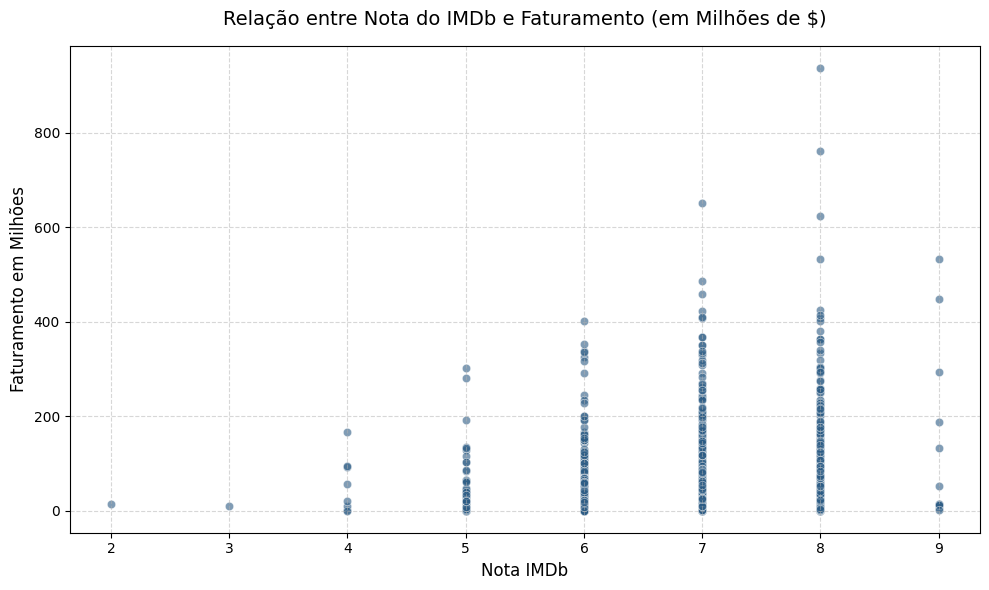

In [17]:
with get_connection() as conn:
    query_imdb = """
    SELECT Title, Rating, RevenueMillions
    FROM IMDB_movies
    WHERE RevenueMillions IS NOT NULL AND Rating IS NOT NULL
    """
    df_imdb = pd.read_sql(query_imdb, con=conn)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_imdb, x='Rating', y='RevenueMillions', alpha=0.6, color='#2B5B84')


plt.title('Relação entre Nota do IMDb e Faturamento (em Milhões de $)', fontsize=14, pad=15)
plt.xlabel('Nota IMDb', fontsize=12)
plt.ylabel('Faturamento em Milhões', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('imdb_scatter.png', dpi=300)
plt.show()

---

## Conclusão

Agradeço à equipe da Looqbox pela oportunidade! O script em Python e as queries originais, conforme solicitados, também foram enviados através do meu Pull Request no repositório oficial do desafio. Fico à disposição para responder qualquer dúvida.

---